# Simple Liner Regression

# Data

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from holoviews.examples.gallery.apps.bokeh.crossfilter import color
from pandas.core.common import random_state

In [3]:
from sklearn.datasets import make_regression
import pandas as pd

X, y = make_regression(
    n_samples=200,
    n_features=1,
    n_informative=1,
    noise=30,
    random_state=42
)


In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

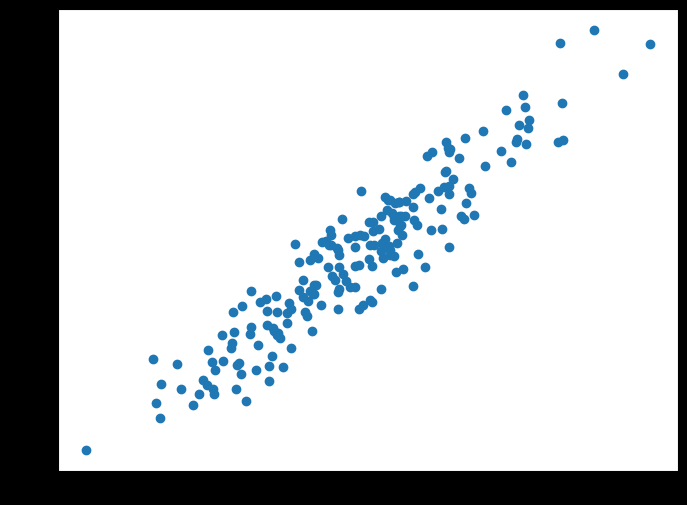

In [4]:
plt.figure(figsize=(8,6))
plt.style.use('default')
plt.scatter(X,y)

In [53]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_sk = lr.predict(X_train)

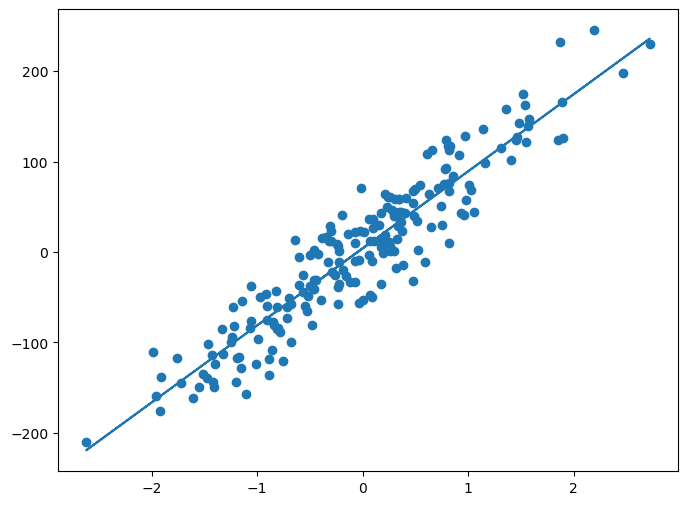

In [59]:
plt.figure(figsize=(8,6))
plt.plot(X_train,pred_sk)
plt.style.use('default')
plt.scatter(X,y)

In [48]:
class Lr:
    def __init__(self):
        self.baise = 1
    def fit(self,X,y):
        x_bar = np.mean(X)
        y_bar = np.mean(y)
        x_pred = [i - x_bar for i in X][0]
        x2_pred = [(i - x_bar)**2 for i in X][0]
        y_pred = [j - y_bar for j in y][0]
        self.m = x_pred*y_pred / x2_pred
        self.b = x_bar*self.m - y_bar
    def predict(self, X):
        y = []
        for x in X:
            y.append((self.m*x + self.b))
        return y

In [60]:
model = Lr()
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [61]:
pred = np.array(pred).ravel()

In [62]:
print(pred.shape)

(40,)


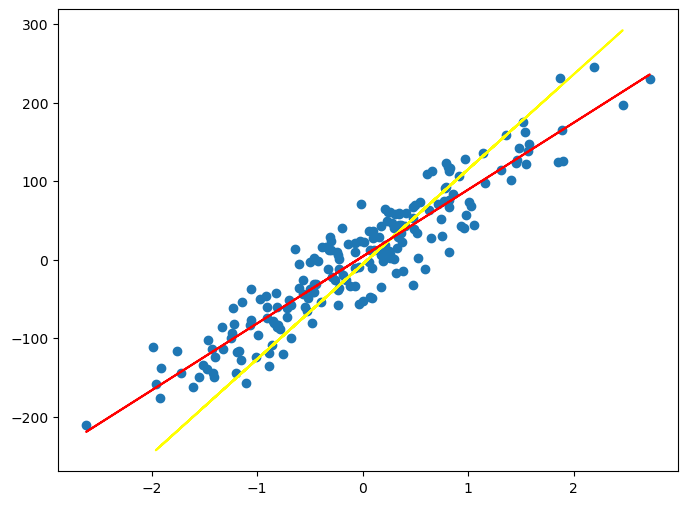

In [63]:
plt.figure(figsize=(8,6))
plt.plot(X_test,pred,color='yellow')
plt.plot(X_train,pred_sk,color='red')
plt.style.use('default')
plt.scatter(X,y)